In [1]:
import pandas as pd
df = pd.read_csv("Walmart.csv")
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [2]:
df.groupby('Store')['Weekly_Sales'].sum().sort_values(ascending=False).head()

Store
20    3.013978e+08
4     2.995440e+08
14    2.889999e+08
13    2.865177e+08
2     2.753824e+08
Name: Weekly_Sales, dtype: float64

In [3]:
df.groupby('Holiday_Flag')['Weekly_Sales'].mean()

Holiday_Flag
0    1.041256e+06
1    1.122888e+06
Name: Weekly_Sales, dtype: float64

In [4]:
import matplotlib.pyplot as plt


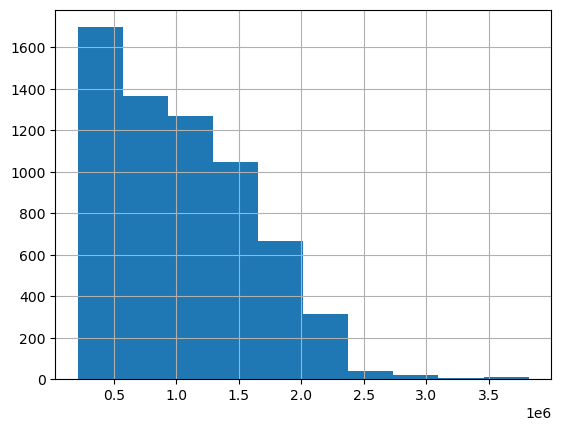

In [5]:
df['Weekly_Sales'].hist()
plt.show()

In [6]:
# Missing values check karne ke liye
print("Missing Values:\n", df.isnull().sum())

# Data ki statistical summary (Mean, Max, Min, etc.) dekhne ke liye
df.describe()


Missing Values:
 Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64


,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000


              Weekly_Sales  Temperature  Fuel_Price       CPI  Unemployment
Weekly_Sales      1.000000    -0.063810    0.009464 -0.072634     -0.106176
Temperature      -0.063810     1.000000    0.144982  0.176888      0.101158
Fuel_Price        0.009464     0.144982    1.000000 -0.170642     -0.034684
CPI              -0.072634     0.176888   -0.170642  1.000000     -0.302020
Unemployment     -0.106176     0.101158   -0.034684 -0.302020      1.000000


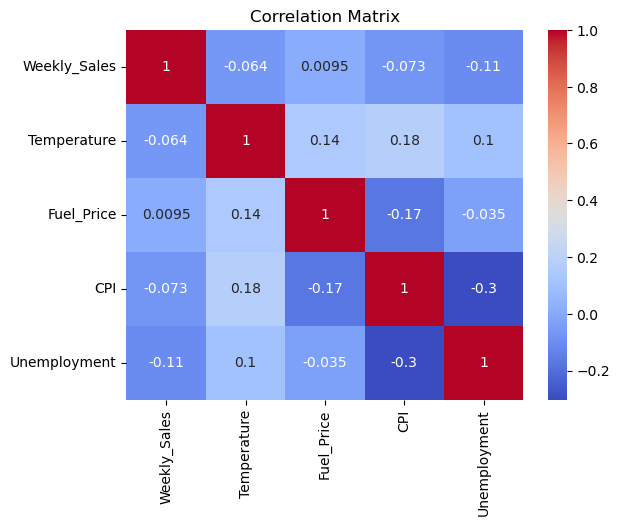

In [7]:
# Correlation matrix nikalne ke liye
correlation = df[['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']].corr()
print(correlation)

# Agar aapko iska heatmap banana hai to:
import seaborn as sns
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

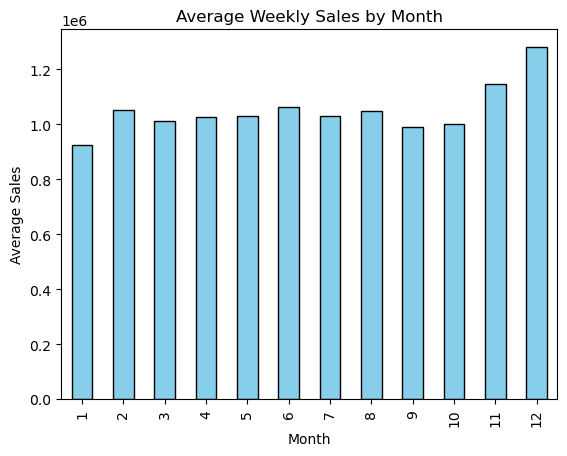

In [8]:
# Date column ko datetime format mein convert karna
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

# Month aur Year ke naye columns banana
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

# Mahine ke hisab se Average Sales ka bar chart
df.groupby('Month')['Weekly_Sales'].mean().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Average Weekly Sales by Month')
plt.xlabel('Month')
plt.ylabel('Average Sales')
plt.show()

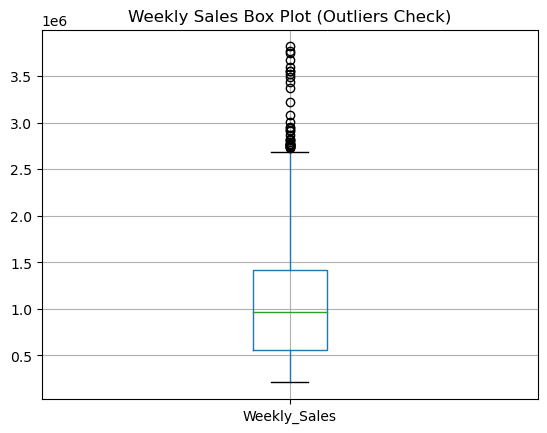

In [9]:
# Sales ka Box Plot banana
df.boxplot(column='Weekly_Sales')
plt.title('Weekly Sales Box Plot (Outliers Check)')
plt.show()